# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI Writing Detection Dataset](https://www.kaggle.com/datasets/razanihababdellatif/ai-vs-human-academic-writing-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ai_writing_detection_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Student_ID,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Is_AI_Assisted
0,16959e76,Lab_Report,Postgraduate,Native,1552,16.90,8,0.62,0.11,11.85,129.05,16.0,24.70,3.02,0.0,0.08,2.01,Arial,18,0
1,0a304e7f,Research_Paper,Undergraduate,Native,950,16.71,5,0.47,0.31,10.34,236.60,23.0,38.84,1.71,15.0,0.07,1.72,Helvetica,15,0
2,6e629f9f,Essay,Undergraduate,Non_Native,1103,22.10,1,0.76,0.38,14.35,4.72,4.0,0.00,0.41,0.0,0.08,2.35,Arial,17,1
3,16334d32,Essay,Postgraduate,Native,1189,20.00,7,0.61,0.26,10.93,NaN,24.0,41.92,3.06,5.0,0.05,1.68,Times New Roman,5,0
4,54d8e254,Essay,Undergraduate,Native,1035,22.67,2,0.80,0.33,15.30,16.82,2.0,0.00,2.78,1.0,0.09,2.90,Helvetica,8,1


## last Five row

In [4]:
df.tail()

,Student_ID,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Is_AI_Assisted
10195,789f9003,Research_Paper,Undergraduate,Non_Native,1216,10.30,6,0.48,0.21,8.07,121.03,28.0,45.40,2.65,20.0,0.05,1.64,Arial,18,0
10196,d74b373f,Essay,Postgraduate,Native,1062,10.60,6,0.41,0.32,15.08,142.36,25.0,37.91,NaN,4.0,0.06,1.66,Arial,15,0
10197,309522b4,Essay,High_School,Non_Native,950,18.67,5,0.63,0.24,12.60,180.62,23.0,53.38,9.64,8.0,0.00,1.98,Helvetica,20,0
10198,01b91f92,Literature_Review,Undergraduate,Native,1012,20.73,6,0.52,0.05,10.16,146.61,28.0,69.99,NaN,28.0,0.06,1.10,Times New Roman,23,0
10199,4afcd3b1,Research_Paper,Undergraduate,Native,1590,14.37,7,0.75,0.13,6.75,259.88,NaN,18.06,NaN,21.0,0.08,2.10,Arial,22,0


## Shape of our dataset

In [5]:
df.shape

(10200, 20)

## List out all columns

In [6]:
df.columns

Index(['Student_ID', 'Submission_Type', 'Academic_Level', 'Primary_Language',
       'Word_Count', 'Average_Sentence_Length', 'Grammar_Errors',
       'Vocabulary_Richness', 'Passive_Voice_Ratio', 'Reading_Level',
       'Editing_Time', 'Revision_Count', 'Typing_Speed', 'Plagiarism_Score',
       'Citation_Count', 'Punctuation_Density', 'Sentence_Complexity',
       'Font_Family', 'Submission_Hour', 'Is_AI_Assisted'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Student_ID                  object
Submission_Type             object
Academic_Level              object
Primary_Language            object
Word_Count                   int64
Average_Sentence_Length    float64
Grammar_Errors               int64
Vocabulary_Richness        float64
Passive_Voice_Ratio        float64
Reading_Level              float64
Editing_Time               float64
Revision_Count             float64
Typing_Speed               float64
Plagiarism_Score           float64
Citation_Count             float64
Punctuation_Density        float64
Sentence_Complexity        float64
Font_Family                 object
Submission_Hour              int64
Is_AI_Assisted               int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               10200 non-null  object 
 1   Submission_Type          10200 non-null  object 
 2   Academic_Level           10200 non-null  object 
 3   Primary_Language         10200 non-null  object 
 4   Word_Count               10200 non-null  int64  
 5   Average_Sentence_Length  10200 non-null  float64
 6   Grammar_Errors           10200 non-null  int64  
 7   Vocabulary_Richness      10200 non-null  float64
 8   Passive_Voice_Ratio      10200 non-null  float64
 9   Reading_Level            10200 non-null  float64
 10  Editing_Time             9311 non-null   float64
 11  Revision_Count           8687 non-null   float64
 12  Typing_Speed             9197 non-null   float64
 13  Plagiarism_Score         9387 non-null   float64
 14  Citation_Count        

## Check Null Value

In [9]:
df.isnull().sum()

Student_ID                    0
Submission_Type               0
Academic_Level                0
Primary_Language              0
Word_Count                    0
Average_Sentence_Length       0
Grammar_Errors                0
Vocabulary_Richness           0
Passive_Voice_Ratio           0
Reading_Level                 0
Editing_Time                889
Revision_Count             1513
Typing_Speed               1003
Plagiarism_Score            813
Citation_Count              993
Punctuation_Density           0
Sentence_Complexity           0
Font_Family                   0
Submission_Hour               0
Is_AI_Assisted                0
dtype: int64

## Drop Null Features

In [10]:
df.drop(columns=['Editing_Time', 'Revision_Count', 'Typing_Speed', 'Plagiarism_Score', 'Citation_Count'], inplace = True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(200)

## Drop Null Rows

In [12]:
df.drop_duplicates(inplace=True)

## Summary

In [13]:
df.describe()

,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Punctuation_Density,Sentence_Complexity,Submission_Hour,Is_AI_Assisted
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1200.971400,16.926677,7.335300,0.622310,0.204663,11.478234,0.053976,1.931766,11.558300,0.144800
std,394.951282,4.639200,5.057295,0.098771,0.096760,2.538285,0.021659,0.575410,6.940923,0.351917
min,300.000000,5.000000,0.000000,0.290000,0.000000,5.000000,0.000000,1.000000,0.000000,0.000000
25%,925.000000,13.610000,5.000000,0.550000,0.140000,9.700000,0.040000,1.480000,5.000000,0.000000
50%,1196.000000,17.070000,7.000000,0.620000,0.200000,11.570000,0.050000,1.930000,12.000000,0.000000
75%,1470.000000,20.622500,9.000000,0.700000,0.270000,13.420000,0.070000,2.360000,18.000000,0.000000
max,2588.000000,33.620000,78.000000,0.900000,0.520000,20.000000,0.130000,4.060000,23.000000,1.000000


# EDA

In [14]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

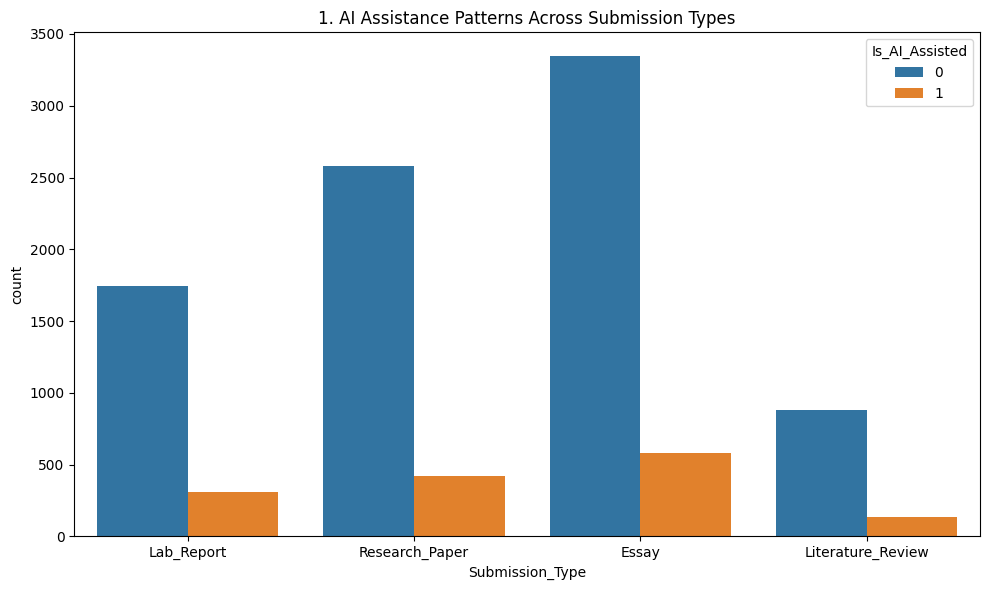

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Submission_Type', hue='Is_AI_Assisted')
plt.title(f'{plot_no}. AI Assistance Patterns Across Submission Types')
show_fig()
plot_no += 1

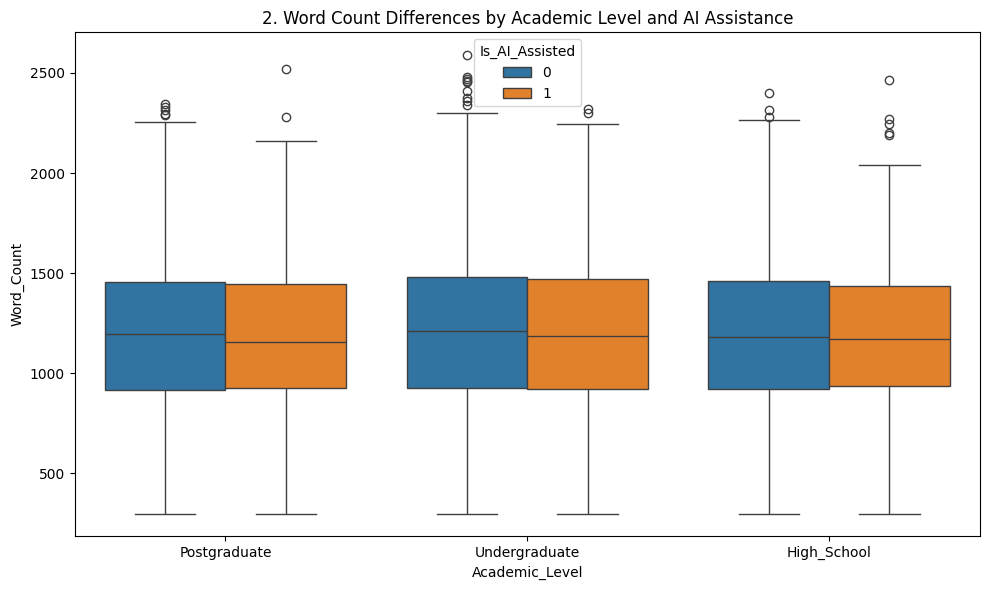

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Academic_Level', y='Word_Count', hue='Is_AI_Assisted')
plt.title(f'{plot_no}. Word Count Differences by Academic Level and AI Assistance')
show_fig()
plot_no += 1

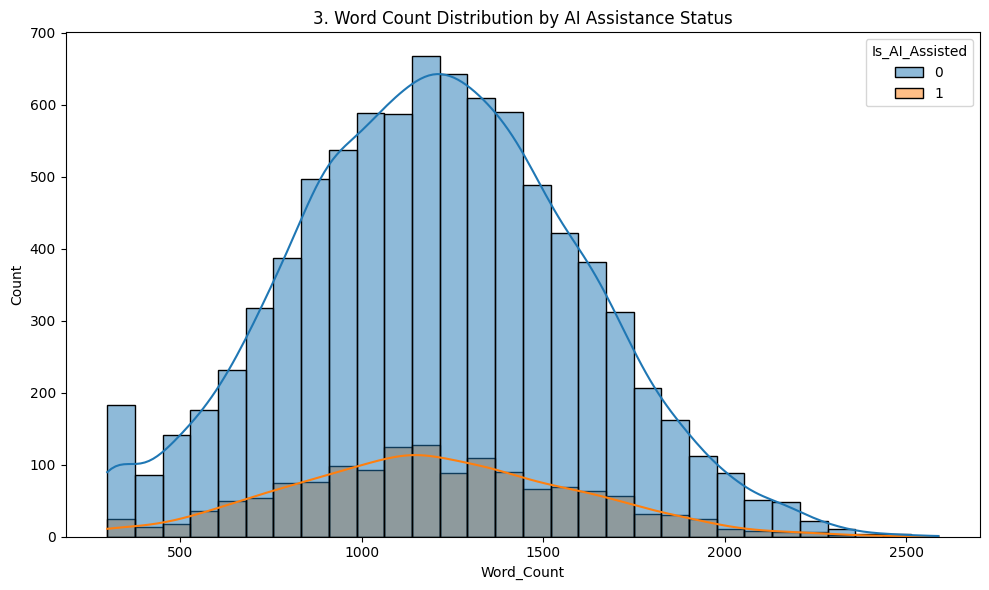

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Word_Count', hue='Is_AI_Assisted', kde=True, bins=30)
plt.title(f'{plot_no}. Word Count Distribution by AI Assistance Status')
show_fig()
plot_no += 1

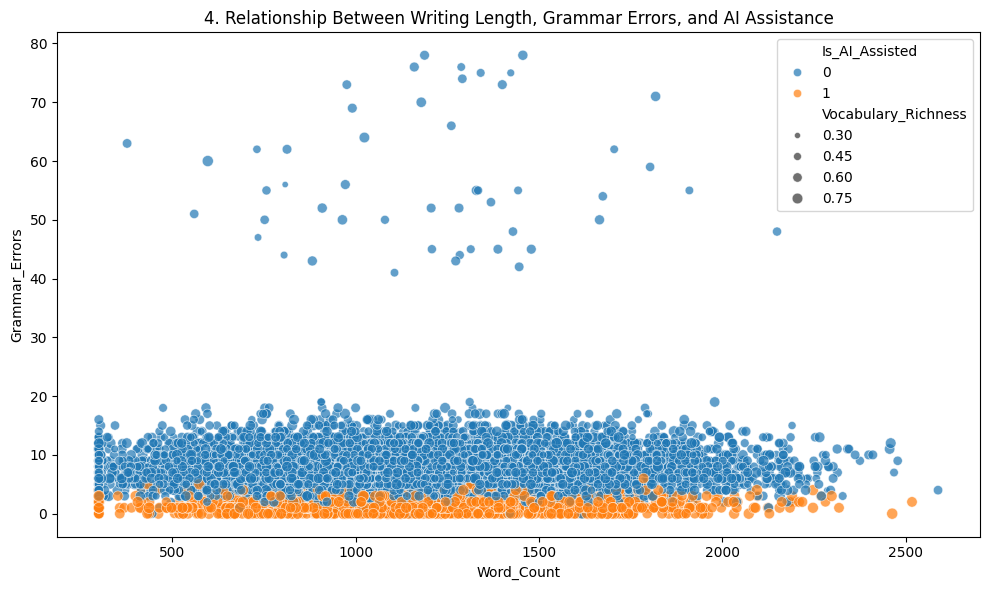

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Word_Count', y='Grammar_Errors', hue='Is_AI_Assisted', size='Vocabulary_Richness', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Writing Length, Grammar Errors, and AI Assistance')
show_fig()
plot_no += 1

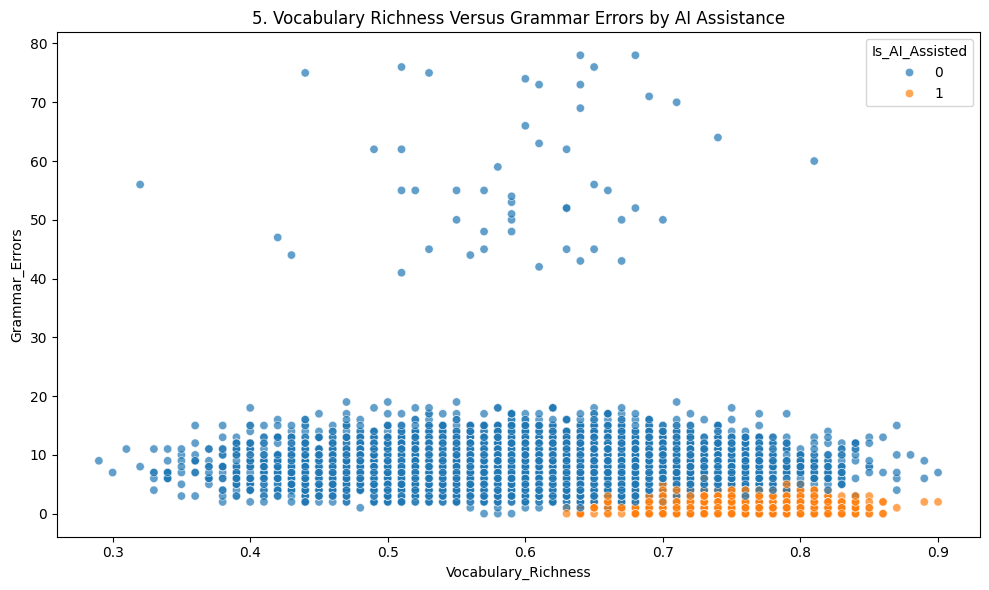

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Vocabulary_Richness', y='Grammar_Errors', hue='Is_AI_Assisted', alpha=0.7)
plt.title(f'{plot_no}. Vocabulary Richness Versus Grammar Errors by AI Assistance')
show_fig()
plot_no += 1

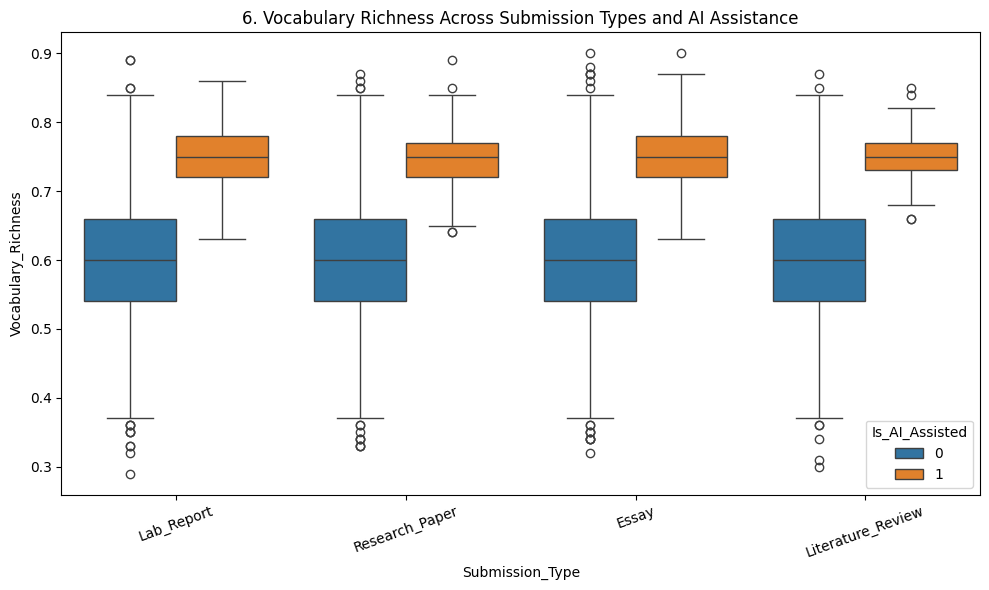

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Submission_Type', y='Vocabulary_Richness', hue='Is_AI_Assisted')
plt.title(f'{plot_no}. Vocabulary Richness Across Submission Types and AI Assistance')
plt.xticks(rotation=20)
show_fig()
plot_no += 1

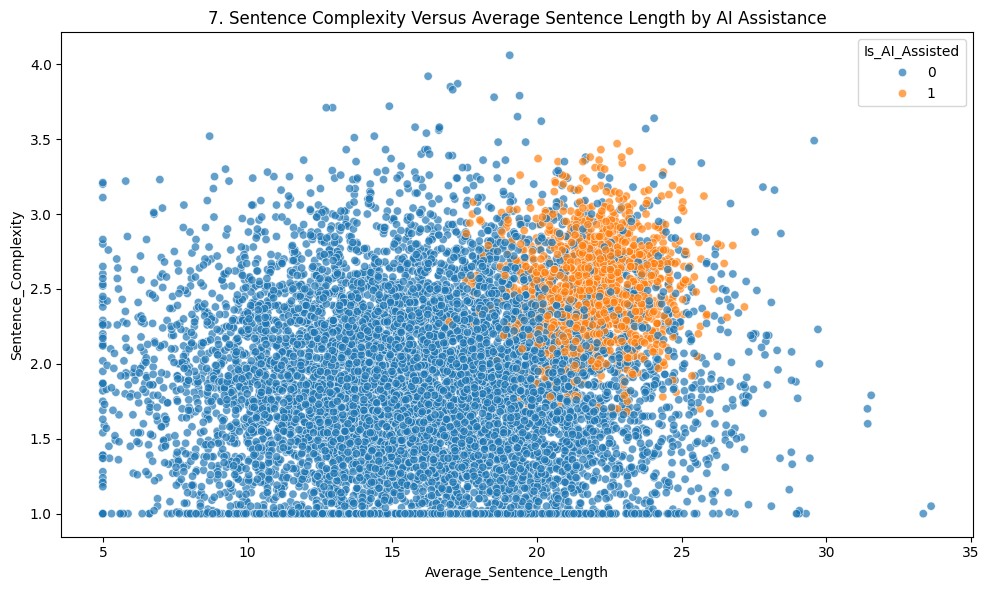

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Average_Sentence_Length', y='Sentence_Complexity', hue='Is_AI_Assisted', alpha=0.7)
plt.title(f'{plot_no}. Sentence Complexity Versus Average Sentence Length by AI Assistance')
show_fig()
plot_no += 1

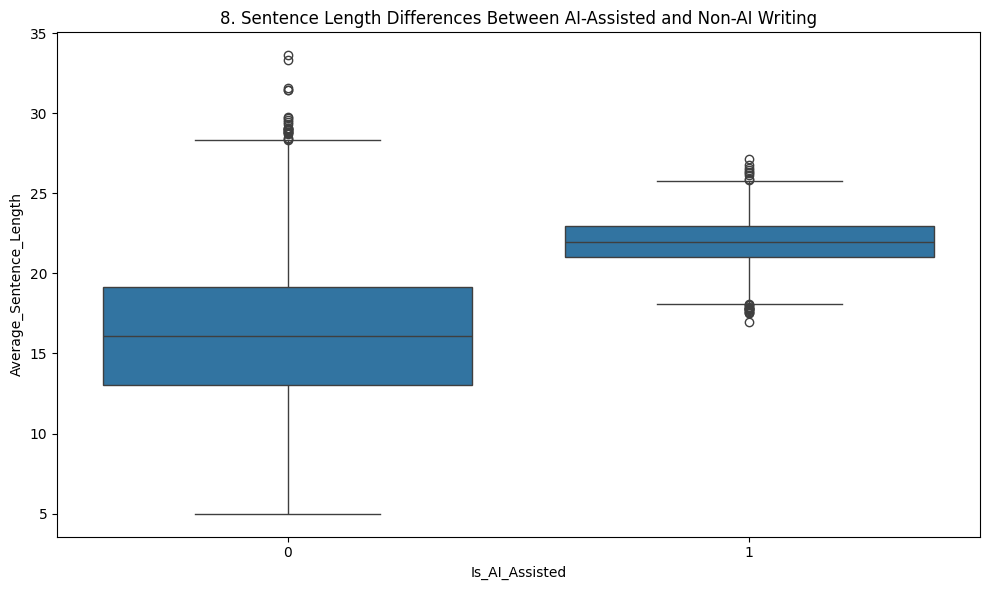

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Is_AI_Assisted', y='Average_Sentence_Length')
plt.title(f'{plot_no}. Sentence Length Differences Between AI-Assisted and Non-AI Writing')
show_fig()
plot_no += 1

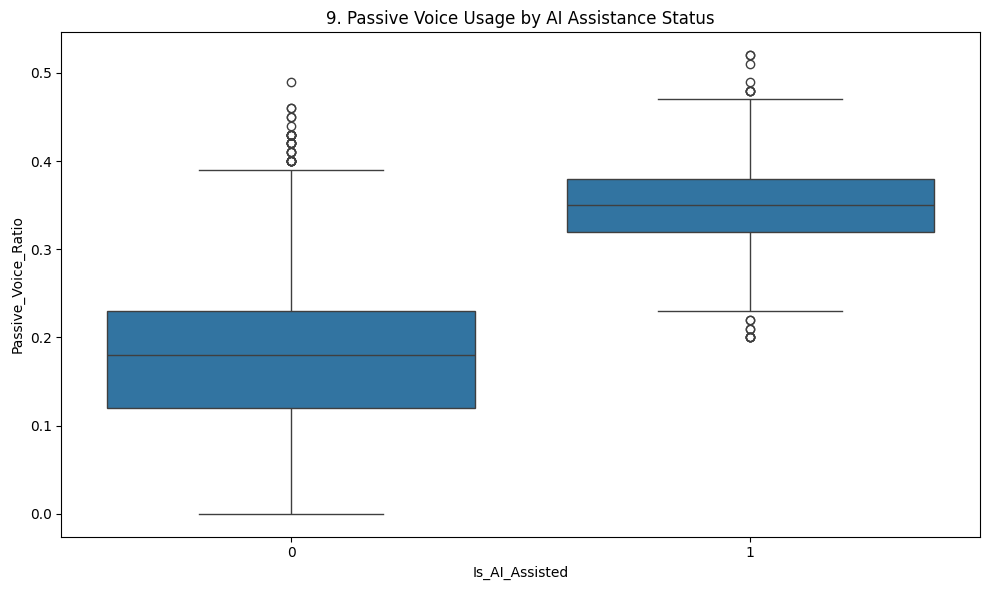

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Is_AI_Assisted', y='Passive_Voice_Ratio')
plt.title(f'{plot_no}. Passive Voice Usage by AI Assistance Status')
show_fig()
plot_no += 1

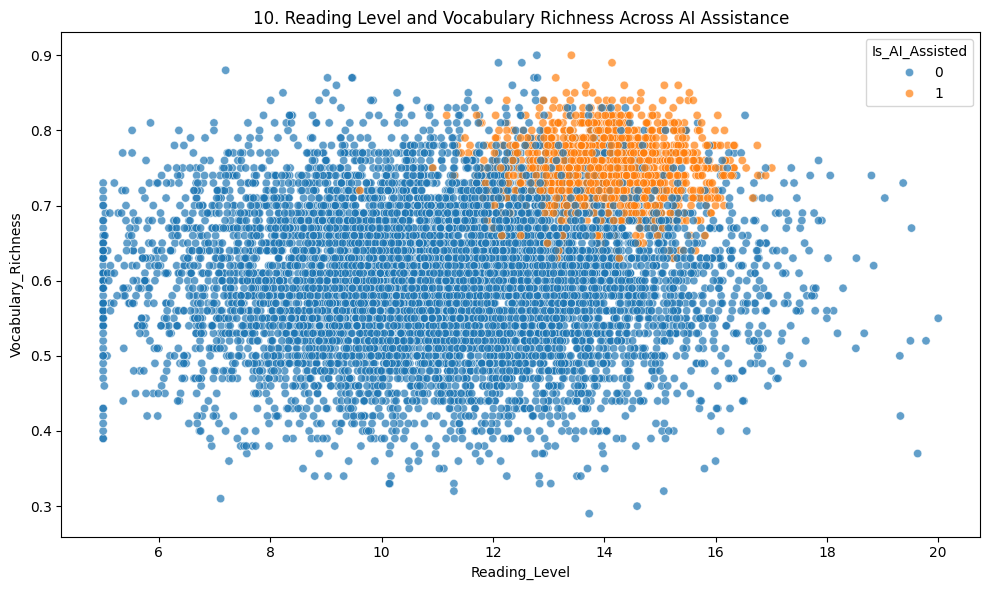

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Reading_Level', y='Vocabulary_Richness', hue='Is_AI_Assisted', alpha=0.7)
plt.title(f'{plot_no}. Reading Level and Vocabulary Richness Across AI Assistance')
show_fig()
plot_no += 1

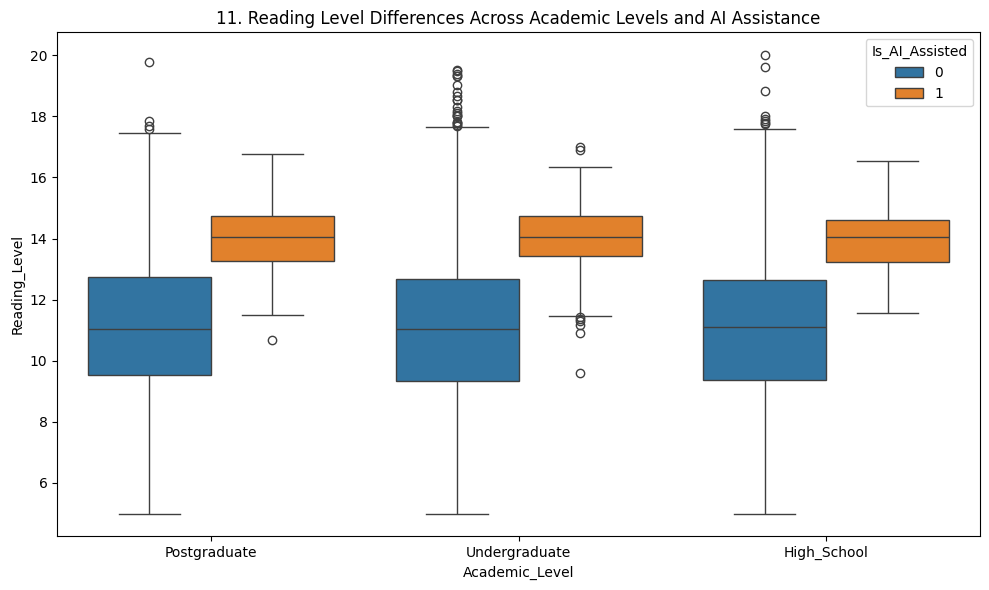

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Academic_Level', y='Reading_Level', hue='Is_AI_Assisted')
plt.title(f'{plot_no}. Reading Level Differences Across Academic Levels and AI Assistance')
show_fig()
plot_no += 1

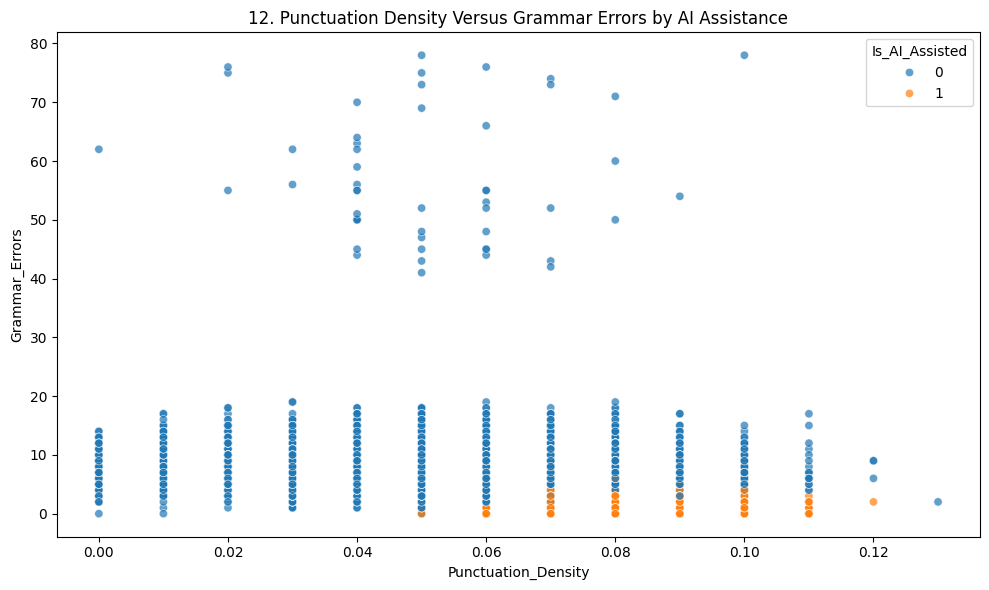

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Punctuation_Density', y='Grammar_Errors', hue='Is_AI_Assisted', alpha=0.7)
plt.title(f'{plot_no}. Punctuation Density Versus Grammar Errors by AI Assistance')
show_fig()
plot_no += 1

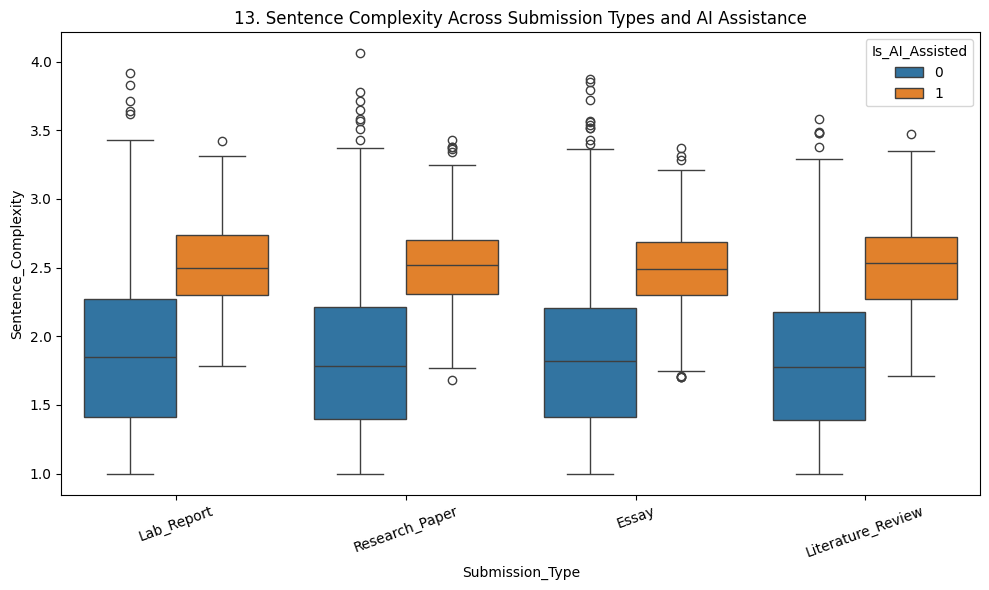

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Submission_Type', y='Sentence_Complexity', hue='Is_AI_Assisted')
plt.title(f'{plot_no}. Sentence Complexity Across Submission Types and AI Assistance')
plt.xticks(rotation=20)
show_fig()
plot_no += 1

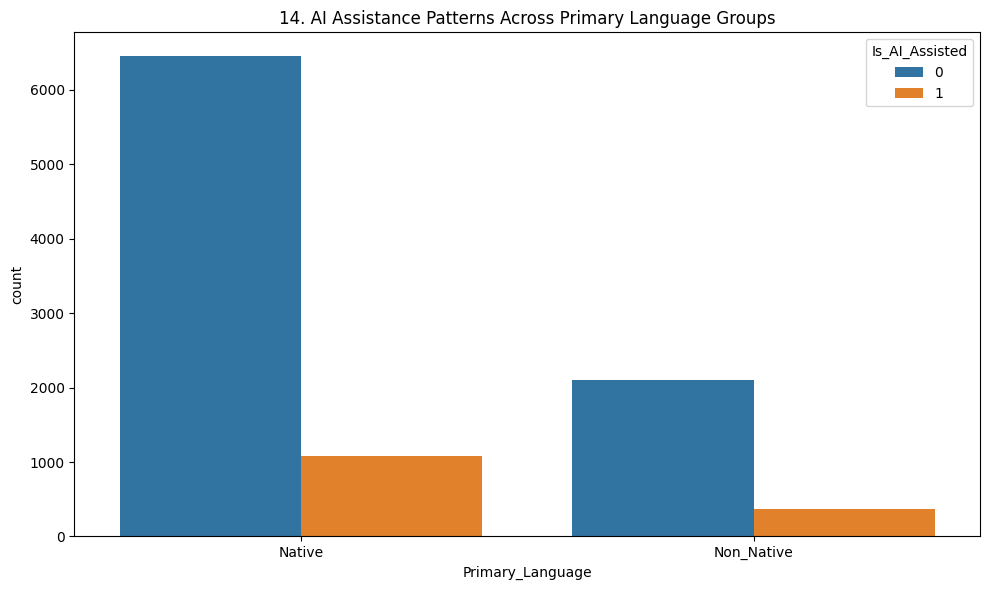

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Primary_Language', hue='Is_AI_Assisted')
plt.title(f'{plot_no}. AI Assistance Patterns Across Primary Language Groups')
show_fig()
plot_no += 1

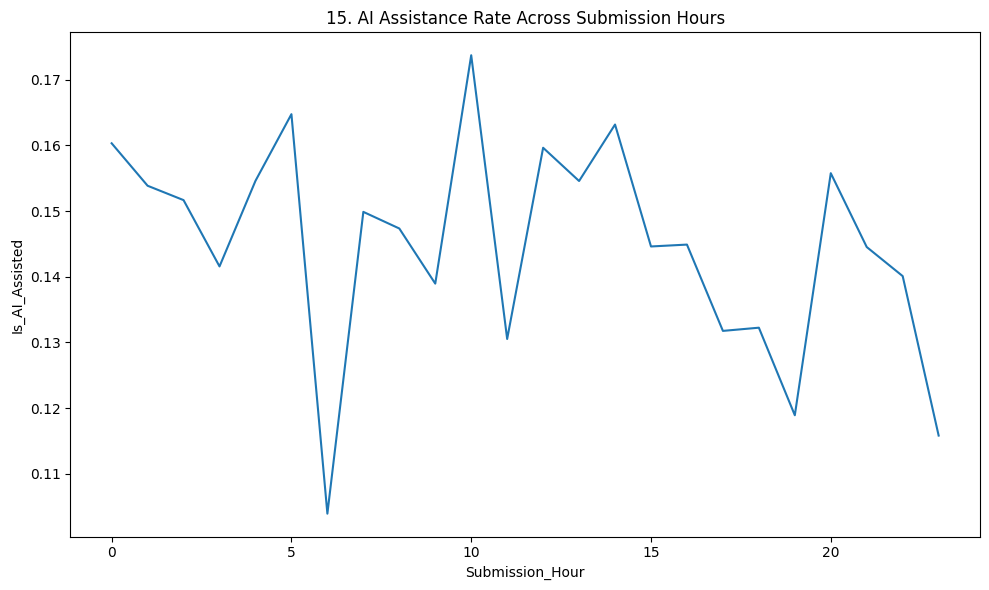

In [29]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Submission_Hour', y='Is_AI_Assisted', errorbar=None)
plt.title(f'{plot_no}. AI Assistance Rate Across Submission Hours')
show_fig()
plot_no += 1

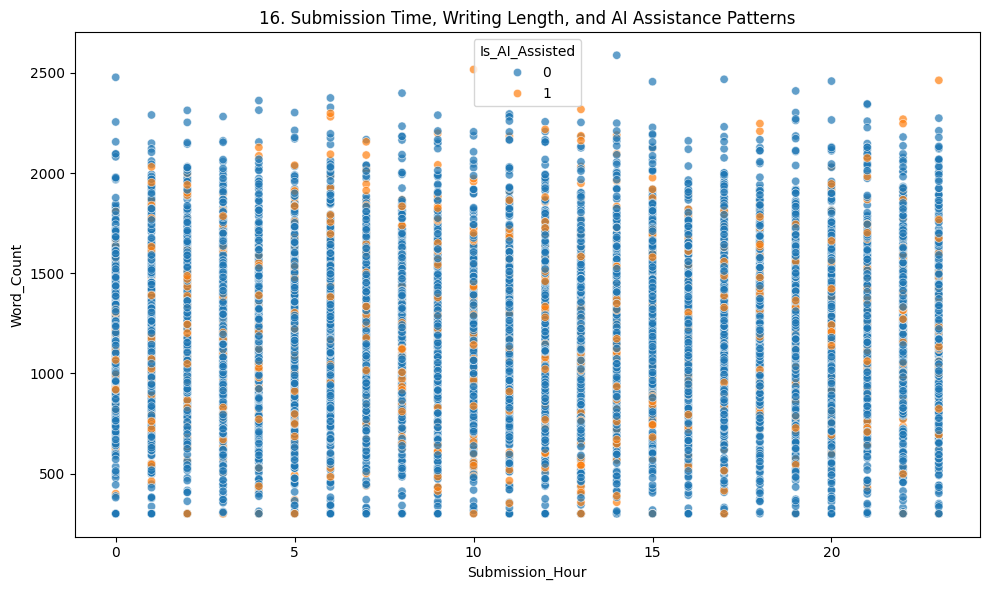

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Submission_Hour', y='Word_Count', hue='Is_AI_Assisted', alpha=0.7)
plt.title(f'{plot_no}. Submission Time, Writing Length, and AI Assistance Patterns')
show_fig()
plot_no += 1

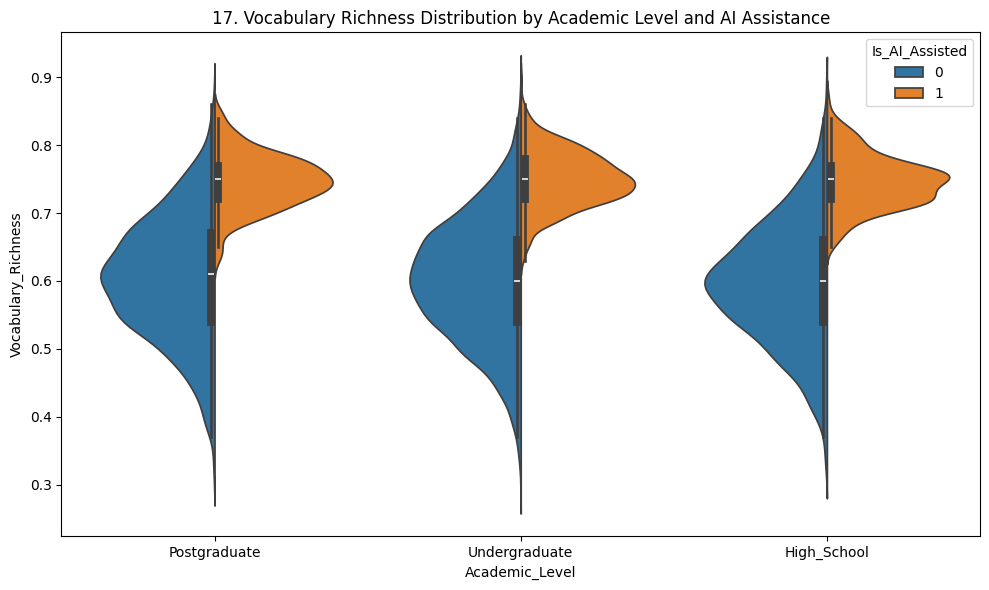

In [31]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Academic_Level', y='Vocabulary_Richness', hue='Is_AI_Assisted', split=True)
plt.title(f'{plot_no}. Vocabulary Richness Distribution by Academic Level and AI Assistance')
show_fig()
plot_no += 1

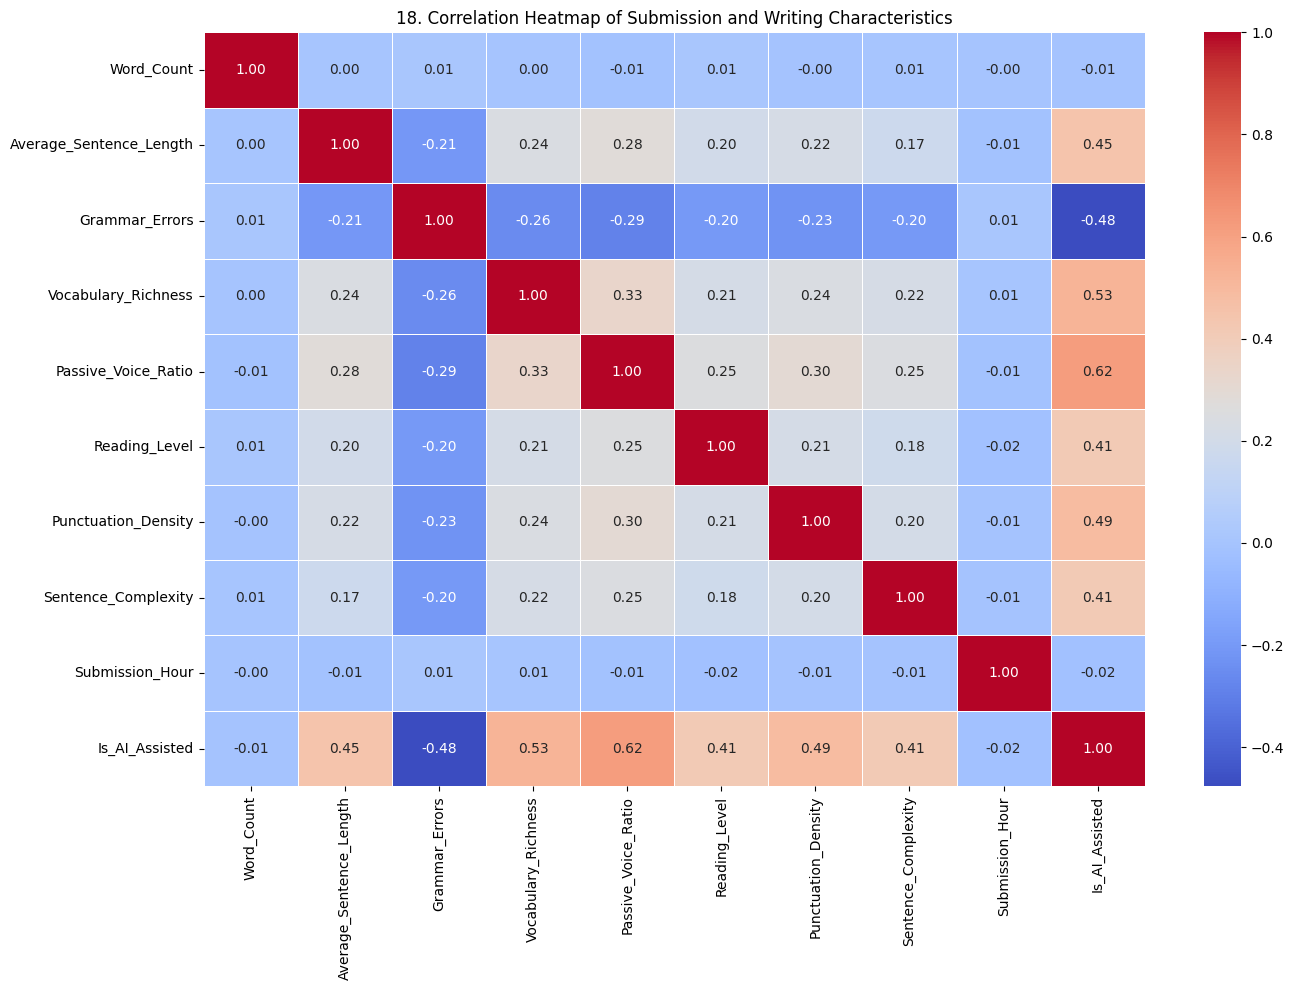

In [32]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Submission and Writing Characteristics')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [33]:
X = df.drop(columns=['Student_ID', 'Is_AI_Assisted'])
y = df['Is_AI_Assisted']

## Separate numerical and categorical features

In [34]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

## Preprocess numerical features

In [35]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Preprocess categorical features

In [36]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## Combine preprocessing steps

In [37]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## Create Logistic Regression model

In [38]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

## Split dataset

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train model

In [40]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Make predictions

In [41]:
y_pred = model.predict(X_test)

## Calculate accuracy

In [42]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.4f}')
print(f'Model Accuracy: {accuracy * 100:.2f}%')

Model Accuracy: 0.9990
Model Accuracy: 99.90%


## Plot confusion matrix

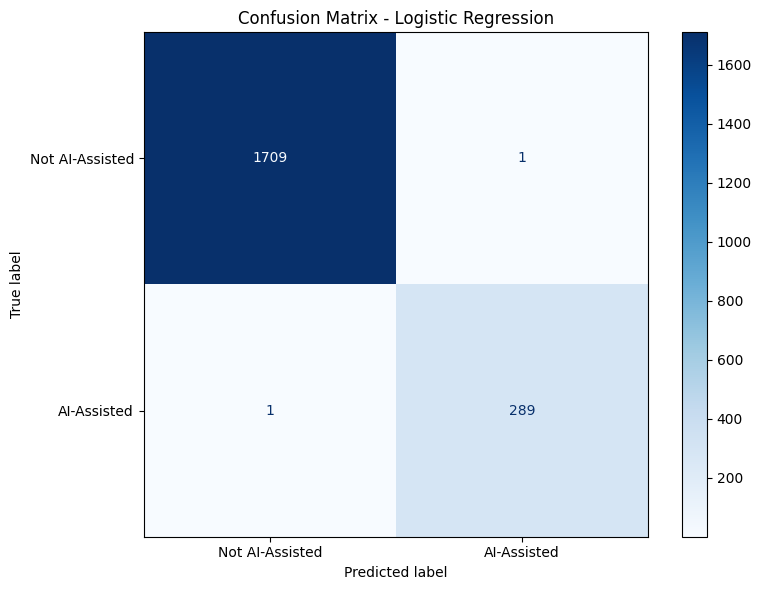

In [43]:
fig = plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not AI-Assisted', 'AI-Assisted']
).plot(ax=plt.gca(), cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()